<a href="https://colab.research.google.com/github/Bamboohoccode/LLMs_From_Scratch/blob/main/Chapter_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

tensor([[0.2260, 0.3470, 0.0000, 0.2216, 0.0000, 0.0000],
        [0.2133, 0.2394, 0.0000, 0.5198, 0.3297, 0.0000]],
       grad_fn=<ReluBackward0>)


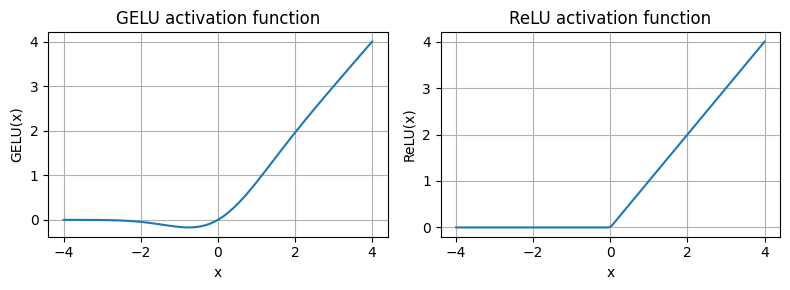

layers.0.0.weight has gradient mean of 0.017917918041348457
layers.1.0.weight has gradient mean of 0.022290976718068123
layers.2.0.weight has gradient mean of 0.011262616142630577
layers.3.0.weight has gradient mean of 0.03297117352485657
layers.4.0.weight has gradient mean of 0.025448836386203766
output.weight has gradient mean of 0.14177103340625763
layers.0.0.weight has gradient mean of 7.291760994121432e-06
layers.1.0.weight has gradient mean of 3.326115620438941e-05
layers.2.0.weight has gradient mean of 7.325314800255e-05
layers.3.0.weight has gradient mean of 0.0006181434146128595
layers.4.0.weight has gradient mean of 0.002277341205626726
output.weight has gradient mean of 0.011895888485014439
Input shape: torch.Size([2, 4, 768])
Output shape: torch.Size([2, 4, 768])
Input batch:
 tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])

Output shape: torch.Size([2, 4, 50257])
tensor([[[-0.3556, -0.2533, -0.3395,  ...,  0.0093, -0.6117,  0.0429],
         [-0.1311, 

In [ ]:
# 1. Cài đặt thư viện hỗ trợ import file .ipynb
!pip install import-ipynb

import import_ipynb
import os
from google.colab import drive

# 2. Mount Drive (nếu chưa mount)
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# 3. Di chuyển đến thư mục chứa file
os.chdir('/content/drive/MyDrive/Colab Notebooks')

import Chapter_4 as import_4

- Trong PyTorch, model.eval() là một lệnh cực kỳ quan trọng khi bạn chuyển từ giai đoạn huấn luyện (training) sang giai đoạn đánh giá/sử dụng (inference/evaluation).
- Về cơ bản, lệnh này thông báo cho tất cả các lớp (layers) trong mô hình rằng: "Chúng ta không học nữa, hãy hoạt động ở chế độ dự đoán!,Nó ảnh hưởng đến những lớp Dropout và Batch Normalization Layers.

In [ ]:
import torch
import torch.nn as nn
# from Chapter_4 import GPTModel
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

GPT_CONFIG_124M = {
"vocab_size": 50257,
"context_length": 256, #A
"emb_dim": 768,
"n_heads": 12,
"n_layers": 12,
"drop_rate": 0.1, #B
"qkv_bias": False
}
torch.manual_seed(123)
model = import_4.GPTModel(GPT_CONFIG_124M)
model.eval()

GPTModel(
  (tok_embedded): Embedding(50257, 768)
  (pos_embedded): Embedding(256, 768)
  (dropout): Dropout(p=0.1, inplace=False)
  (transformer): Sequential(
    (0): TransformerBlock(
      (LayerNorm1): LayerNorm()
      (LayerNorm2): LayerNorm()
      (att): MultiHeadAttention(
        (W_q): Linear(in_features=768, out_features=768, bias=False)
        (W_k): Linear(in_features=768, out_features=768, bias=False)
        (W_v): Linear(in_features=768, out_features=768, bias=False)
        (dropout): Dropout(p=0.1, inplace=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=False)
          (1): GeLU()
          (2): Linear(in_features=3072, out_features=768, bias=False)
        )
      )
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (LayerNorm1): LayerNorm()
      (LayerNorm2): LayerNorm()

# 5.1.1 Using GPT to generate text

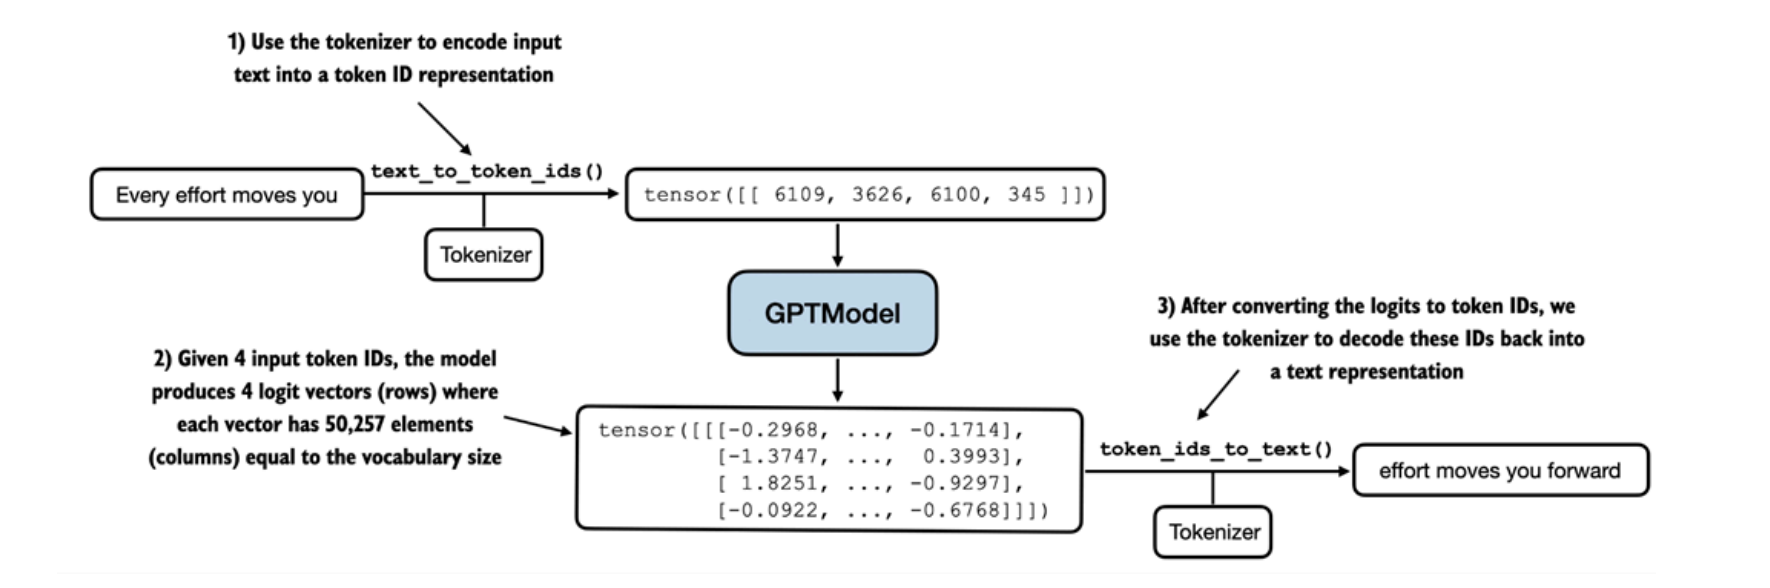

In [ ]:
import tiktoken
def text_to_token_ids(text,tokenizer):
    encoder = tokenizer.encode(text,allowed_special ={'<|endoftext|>'})
    tensor = torch.tensor(encoder).unsqueeze(0) # Corrected line
    return tensor
def token_to_text(text,tokenizer):
    flat = text.squeeze(0)
    return tokenizer.decode(flat.tolist())
start_content = "Every effort moves you"
tokenizer = tiktoken.get_encoding("gpt2")

token_ids = import_4.generate_text_simple(
model=model,
X=text_to_token_ids(start_content, tokenizer),
max_new_tokens=1,
context_size=GPT_CONFIG_124M["context_length"]
)
print("The predict sentence is: ",token_to_text(token_ids,tokenizer))

The predict sentence is:  Every effort moves you misunderstood


# 5.1.2 Calculating the text generation loss

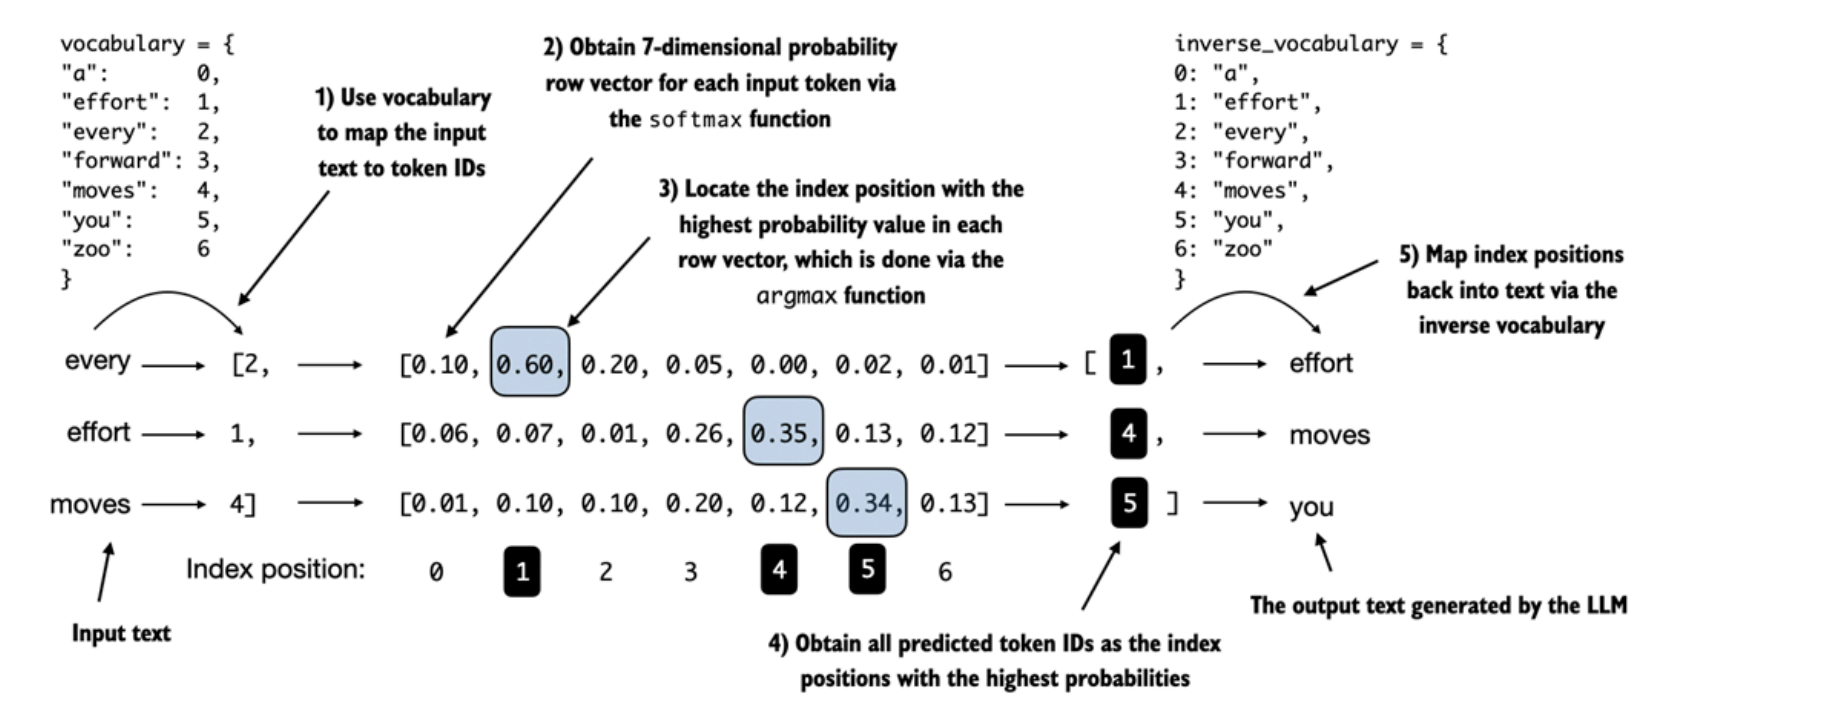

In [ ]:
inputs = torch.tensor([[16833, 3626, 6100], # ["every effort moves",
[40, 1107, 588]]) # "I really like"]

targets = torch.tensor([[3626, 6100, 345 ], # [" effort moves you",
[107, 588, 11311]]) # " really like chocolate"]

In [ ]:
with torch.no_grad():
    logits = model(inputs)
probas = torch.softmax(logits,dim = -1)
probas.shape

torch.Size([2, 3, 50257])

The model's wrong in prediction becuz it hasn't been trained yet.

In [ ]:
token_ids = torch.argmax(probas,dim = -1)
token_ids[0]
print(token_to_text(targets[0],tokenizer))
print(token_to_text(token_ids[0],tokenizer))

 effort moves you
 intest QUtested


For each of the two input texts, we can print the initial softmax probability scores
corresponding to the target tokens via the following code:


In [ ]:
text_idx = 0
target_probas_1 = probas[text_idx, [0, 1, 2], targets[text_idx]] # targets[text_idx] is the probability of targets in probas
print("Text 1:", target_probas_1)
text_idx = 1
target_probas_2 = probas[text_idx, [0, 1, 2], targets[text_idx]]
print("Text 2:", target_probas_2)


Text 1: tensor([5.8453e-06, 3.3045e-06, 3.6188e-06])
Text 2: tensor([2.9977e-05, 1.6690e-05, 4.1649e-06])


We need to maximum there numbers

## Apply cross-entropy

In [ ]:
print("Logits shape:", logits.shape)
print("Targets shape:", targets.shape)


Logits shape: torch.Size([2, 3, 50257])
Targets shape: torch.Size([2, 3])


In [ ]:
logits_flat = logits.flatten(0,1)
target_flat = targets.flatten()
print("Logits shape:", logits_flat.shape)
print("Targets shape:", target_flat.shape)

Logits shape: torch.Size([6, 50257])
Targets shape: torch.Size([6])


PyTorch's cross_entropy function will take care of all these steps for us,so we don't need to transform target shape -> the same with logits shape

In [ ]:
loss = nn.functional.cross_entropy(logits_flat,target_flat)
print(loss)

tensor(11.8340)


In [ ]:
path = "/content/the-verdict.txt"
with open(path,mode = 'r',encoding = "utf-8") as file:
    data = file.read()

In [ ]:
print(len(data))
total_tokens = tokenizer.encode(data)
print(len(total_tokens))

20505
5156


split train-validation data

In [ ]:
train_ratio = 0.90
split_idx = int(train_ratio * len(data))
train_data = data[:split_idx]
val_data = data[split_idx:]

In [ ]:
train_data

'I HAD always thought Jack Gisburn rather a cheap genius--though a good fellow enough--so it was no great surprise to me to hear that, in the height of his glory, he had dropped his painting, married a rich widow, and established himself in a villa on the Riviera. (Though I rather thought it would have been Rome or Florence.)\n\n"The height of his glory"--that was what the women called it. I can hear Mrs. Gideon Thwing--his last Chicago sitter--deploring his unaccountable abdication. "Of course it\'s going to send the value of my picture \'way up; but I don\'t think of that, Mr. Rickham--the loss to Arrt is all I think of." The word, on Mrs. Thwing\'s lips, multiplied its _rs_ as though they were reflected in an endless vista of mirrors. And it was not only the Mrs. Thwings who mourned. Had not the exquisite Hermia Croft, at the last Grafton Gallery show, stopped me before Gisburn\'s "Moon-dancers" to say, with tears in her eyes: "We shall not look upon its like again"?\n\nWell!--even 

In [ ]:
import Chapter_2 as import_2

Total number of character: 20505
I HAD always thought Jack Gisburn rather a cheap genius--though a good fellow enough--so it was no 
['I', ' ', 'HAD', ' ', 'always', ' ', 'thought', ' ', 'Jack', ' ', 'Gisburn', ' ', 'rather', ' ', 'a', ' ', 'cheap', ' ', 'genius', '--', 'though', ' ', 'a', ' ', 'good', ' ', 'fellow', ' ', 'enough', '--', 'so', ' ', 'it', ' ', 'was', ' ', 'no', ' ', 'great', ' ', 'surprise', ' ', 'to', ' ', 'me', ' ', 'to', ' ', 'hear', ' ', 'that', ',', '', ' ', 'in', ' ', 'the', ' ', 'height', ' ', 'of', ' ', 'his', ' ', 'glory', ',', '', ' ', 'he', ' ', 'had', ' ', 'dropped', ' ', 'his', ' ', 'painting', ',', '', ' ', 'married', ' ', 'a', ' ', 'rich', ' ', 'widow', ',', '', ' ', 'and', ' ', 'established', ' ', 'himself', ' ', 'in', ' ', 'a', ' ', 'villa', ' ', 'on', ' ', 'the', ' ', 'Riviera', '.', '', ' ', '', '(', 'Though', ' ', 'I', ' ', 'rather', ' ', 'thought', ' ', 'it', ' ', 'would', ' ', 'have', ' ', 'been', ' ', 'Rome', ' ', 'or', ' ', 'Florence', '.', '', '

In [ ]:
torch.manual_seed(123)
train_dataloader = import_2.dataloaderV1(train_data,batch_size=2,
                                         max_length = GPT_CONFIG_124M['context_length'],
                                         stride = GPT_CONFIG_124M['context_length'],
                                         shuffle = False,
                                         drop_last = False)
valid_dataloader = import_2.dataloaderV1(val_data,batch_size=2,
                                         max_length = GPT_CONFIG_124M['context_length'],
                                         stride = GPT_CONFIG_124M['context_length'],
                                         shuffle = False,
                                         drop_last = False)


In [ ]:
train_dataloader

In [ ]:
def cal_loss(input_batch,target_batch,model,device):
    input_batch,target_batch = input_batch.to(device),target_batch.to(device)
    pre_batch = model(input_batch)
    # print(pre_batch.shape,target_batch.shape)
    loss = nn.functional.cross_entropy(pre_batch.flatten(0,1),target_batch.flatten())
    return loss

In [ ]:
model.to(device)

GPTModel(
  (tok_embedded): Embedding(50257, 768)
  (pos_embedded): Embedding(256, 768)
  (dropout): Dropout(p=0.1, inplace=False)
  (transformer): Sequential(
    (0): TransformerBlock(
      (LayerNorm1): LayerNorm()
      (LayerNorm2): LayerNorm()
      (att): MultiHeadAttention(
        (W_q): Linear(in_features=768, out_features=768, bias=False)
        (W_k): Linear(in_features=768, out_features=768, bias=False)
        (W_v): Linear(in_features=768, out_features=768, bias=False)
        (dropout): Dropout(p=0.1, inplace=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=False)
          (1): GeLU()
          (2): Linear(in_features=3072, out_features=768, bias=False)
        )
      )
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (LayerNorm1): LayerNorm()
      (LayerNorm2): LayerNorm()

In [ ]:
def cal_loss_loader(dataloader,model,device,num_batches = None):
    # Adding num_batches parameters help us to control how many batches have been trained
    if(len(dataloader) == 0):
        return float("nan")
    elif(num_batches == None):
        num_batches = len(dataloader)
    else:
        num_batches = min(num_batches,len(dataloader))
    total_loss = 0
    for i,(input,target) in enumerate(dataloader):
        if(i < num_batches):
            loss = cal_loss(input,target,model,device)
            total_loss += loss.item()
        else:
            break

    return total_loss/num_batches

In [ ]:
with torch.no_grad():
    train_loss = cal_loss_loader(train_dataloader,model,device)
    val_loss = cal_loss_loader(valid_dataloader,model,device)
print(train_loss)
print(val_loss)

11.190040164523655
11.190725326538086


# 5.2 Training an LLM

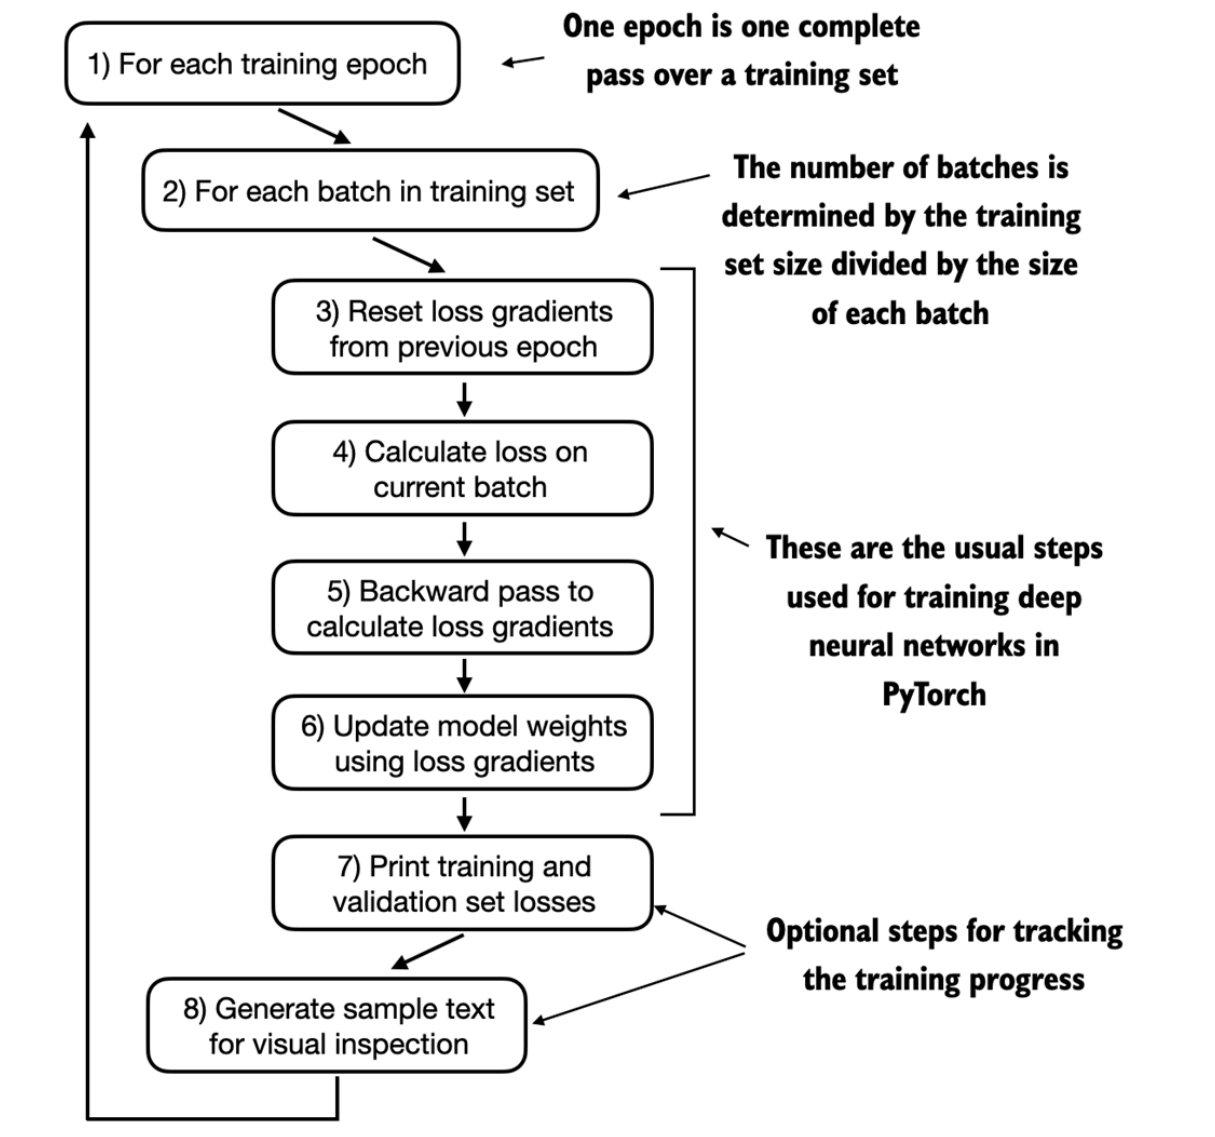

In [ ]:
def train_model_simple(model, train_loader, val_loader, optimizer, device, num_epochs,eval_freq, eval_iter, start_context, tokenizer):
    train_losses = []
    valid_losses = []
    token_seens = 0
    global_step = -1
    for epoch in range(num_epochs):
        model.train()
        for i,(input_batch,target_batch) in enumerate(train_dataloader):
            optimizer.zero_grad() # Zero gradients for each batch

            # cal_loss already moves input_batch and target_batch to device
            # and computes model output and loss
            loss = cal_loss(input_batch, target_batch, model, device)

            loss.backward()
            optimizer.step()
            global_step += 1
            token_seens += input_batch.numel()
            if(global_step % eval_freq == 0):
                train_loss, valid_loss = evaluate_model(model,train_dataloader,valid_dataloader,eval_iter)
                train_losses.append(train_loss)
                valid_losses.append(valid_loss)
                print(f"Ep {epoch+1} (Step {global_step:06d}): "
                      f"Train loss {train_loss:.3f}, Val loss {valid_loss:.3f}") # Corrected val_loss to valid_loss
        generate_and_print_sample(model, tokenizer, device, start_context) # Corrected function call
    return train_losses,valid_losses,token_seens

In [ ]:
def evaluate_model(model,train_dataloader,valid_dataloader,eval_iter):
    model.eval()
    train_loss = cal_loss_loader(train_dataloader,model,device,num_batches = eval_iter)
    val_loss = cal_loss_loader(train_dataloader,model,device,num_batches= eval_iter)
    model.train()
    return train_loss,val_loss


Similar to evaluate_model, the generate_and_print_sample function is a convenience
function that we use to track whether the model improves during the training. In particular,
the generate_and_print_sample function takes a text snippet (start_context) as input,
converts it into token IDs, and feeds it to the LLM to generate a text sample using the
generate_text_simple function we used earlier:

In [ ]:
def generate_and_print_sample(model,tokenizer,device,start_context):
    model.eval()
    context_length = model.pos_embedded.weight.shape[0]
    ids = text_to_token_ids(start_context,tokenizer).to(device)
    with torch.no_grad():
        token_ids = import_4.generate_text_simple(model,ids,max_new_tokens=50,context_size=context_length)
        decoded_text = token_to_text(token_ids,tokenizer)
        print(decoded_text.replace("\n", " ")) # Compact print format
    model.train()

In [ ]:
import torch.optim as optim
torch.manual_seed(123)
model = import_4.GPTModel(GPT_CONFIG_124M)
model.to(device)
lr = 0.004
epochs = 10
optimizer = optim.AdamW(model.parameters(),lr = lr,weight_decay=0.1)
train_losses, val_losses,tokens_seen =train_model_simple(model,train_dataloader,valid_dataloader,optimizer,device,epochs,eval_freq=5,eval_iter = 1,start_context = "Every effort moves you",tokenizer = tokenizer)


Ep 1 (Step 000000): Train loss 6.010, Val loss 6.010
Ep 1 (Step 000005): Train loss 7.335, Val loss 7.335
Every effort moves you..................................................
Ep 2 (Step 000010): Train loss 5.985, Val loss 5.985
Ep 2 (Step 000015): Train loss 8.117, Val loss 8.117
Every effort moves you                                                  
Ep 3 (Step 000020): Train loss 7.266, Val loss 7.266
Ep 3 (Step 000025): Train loss 6.853, Val loss 6.853
Every effort moves you                                                  
Ep 4 (Step 000030): Train loss 5.993, Val loss 5.993
Ep 4 (Step 000035): Train loss 6.947, Val loss 6.947
Every effort moves you                                                  
Ep 5 (Step 000040): Train loss 6.235, Val loss 6.235


KeyboardInterrupt: 

In [ ]:
import matplotlib.pyplot as plt
def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    fig, ax1 = plt.subplots(figsize=(5, 3))
    ax1.plot(epochs_seen, train_losses, label="Training loss")
    ax1.plot(epochs_seen, val_losses, linestyle="-.", label="Validation loss")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    ax2 = ax1.twiny() #A
    ax2.plot(torch.linspace(0,tokens_seen,len(train_losses)), train_losses, alpha=0) #B
    ax2.set_xlabel("Tokens seen")
    fig.tight_layout()
    plt.show()
epochs_tensor = torch.linspace(0, epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)

NameError: name 'train_losses' is not defined

# 5.3 Decoding strategies to control randomness

## temperature scaling, and top-k sampling

In [ ]:
model.to("cpu")
model.eval()

GPTModel(
  (tok_embedded): Embedding(50257, 768)
  (pos_embedded): Embedding(256, 768)
  (dropout): Dropout(p=0.1, inplace=False)
  (transformer): Sequential(
    (0): TransformerBlock(
      (LayerNorm1): LayerNorm()
      (LayerNorm2): LayerNorm()
      (att): MultiHeadAttention(
        (W_q): Linear(in_features=768, out_features=768, bias=False)
        (W_k): Linear(in_features=768, out_features=768, bias=False)
        (W_v): Linear(in_features=768, out_features=768, bias=False)
        (dropout): Dropout(p=0.1, inplace=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=False)
          (1): GeLU()
          (2): Linear(in_features=3072, out_features=768, bias=False)
        )
      )
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (LayerNorm1): LayerNorm()
      (LayerNorm2): LayerNorm()

In [ ]:
token_ids = import_4.generate_text_simple(model,X = text_to_token_ids("Every effort moves you",tokenizer),max_new_tokens= 50,
                                          context_size= GPT_CONFIG_124M['context_length'])
print(f"Predict:{token_to_text(token_ids,tokenizer)}")

KeyboardInterrupt: 

We want to reduce the randomness of the prediction, so temperature'll help.

[Explain the temperature](https://www.youtube.com/watch?v=_YTnZOYxSjE&t=25s)

## Let's have a easy example here

In [ ]:
vocab = {
"closer": 0,
"every": 1,
"effort": 2,
"forward": 3,
"inches": 4,
"moves": 5,
"pizza": 6,
"toward": 7,
"you": 8,
}
inverse_vocab = {v: k for k, v in vocab.items()}
inverse_vocab

In [ ]:
initial_sen = "every effort moves you"
next_token_logits = torch.tensor(
[4.51, 0.89, -1.90, 6.75, 1.63, -1.62, -1.89, 6.28, 1.79]
)

As we can see, it's similar to see the next word is forward,so let's change the temperature =)

In [ ]:
next_token = torch.argmax(next_token_logits).item()
inverse_vocab[next_token]

[Explain about torch.multinomial](https://gemini.google.com/share/7f59c47ef4c1)

In [ ]:
torch.manual_seed(12)
next_token_probabilities = torch.softmax(next_token_logits, dim=-1)
next_token = torch.multinomial(next_token_probabilities, num_samples=1).item()
inverse_vocab[next_token]

The less of temperature, the model prediction is less strict

In [ ]:
def softmax_with_temperature(logits,temperature):
    logits_temperature = logits / temperature
    return torch.softmax(logits_temperature,dim = -1)
temperature_list = [0.1,1,5]
scaled_probas = [softmax_with_temperature(next_token_logits, T) for T in temperature_list]
x = torch.arange(len(vocab))
bar_width = 0.15
fig, ax = plt.subplots(figsize=(5, 3))
for i, T in enumerate(temperature_list):
    rects = ax.bar(x + i * bar_width, scaled_probas[i],
bar_width, label=f'Temperature = {T}')
ax.set_ylabel('Probability')
ax.set_xticks(x)
ax.set_xticklabels(vocab.keys(), rotation=90)
ax.legend()
plt.tight_layout()
plt.show()


# Excercise 5.1
Use the print_sampled_tokens function to print the sampling frequencies of the
softmax probabilities scaled with the temperatures shown in Figure 5.13. How often
is the word "pizza" sampled in each case? Can you think of a faster and more
accurate way to determine how often the word "pizza" is sampled?


In [ ]:
def print_sampled_tokens(probas,temperature):
    torch.manual_seed(123)
    idx_pizza = vocab["pizza"]
    for temp in temperature:
        probas_temp = probas / temp
        sample = [torch.multinomial(probas_temp, num_samples=1).item() for i in range(1000)]
        sampled_ids = torch.bincount(torch.tensor(sample))
        print(f"The frequency of pizza with temperature {temp} is {sampled_ids[idx_pizza]}")
print_sampled_tokens(next_token_probabilities,temperature_list)

## 5.3.2 Top-k sampling

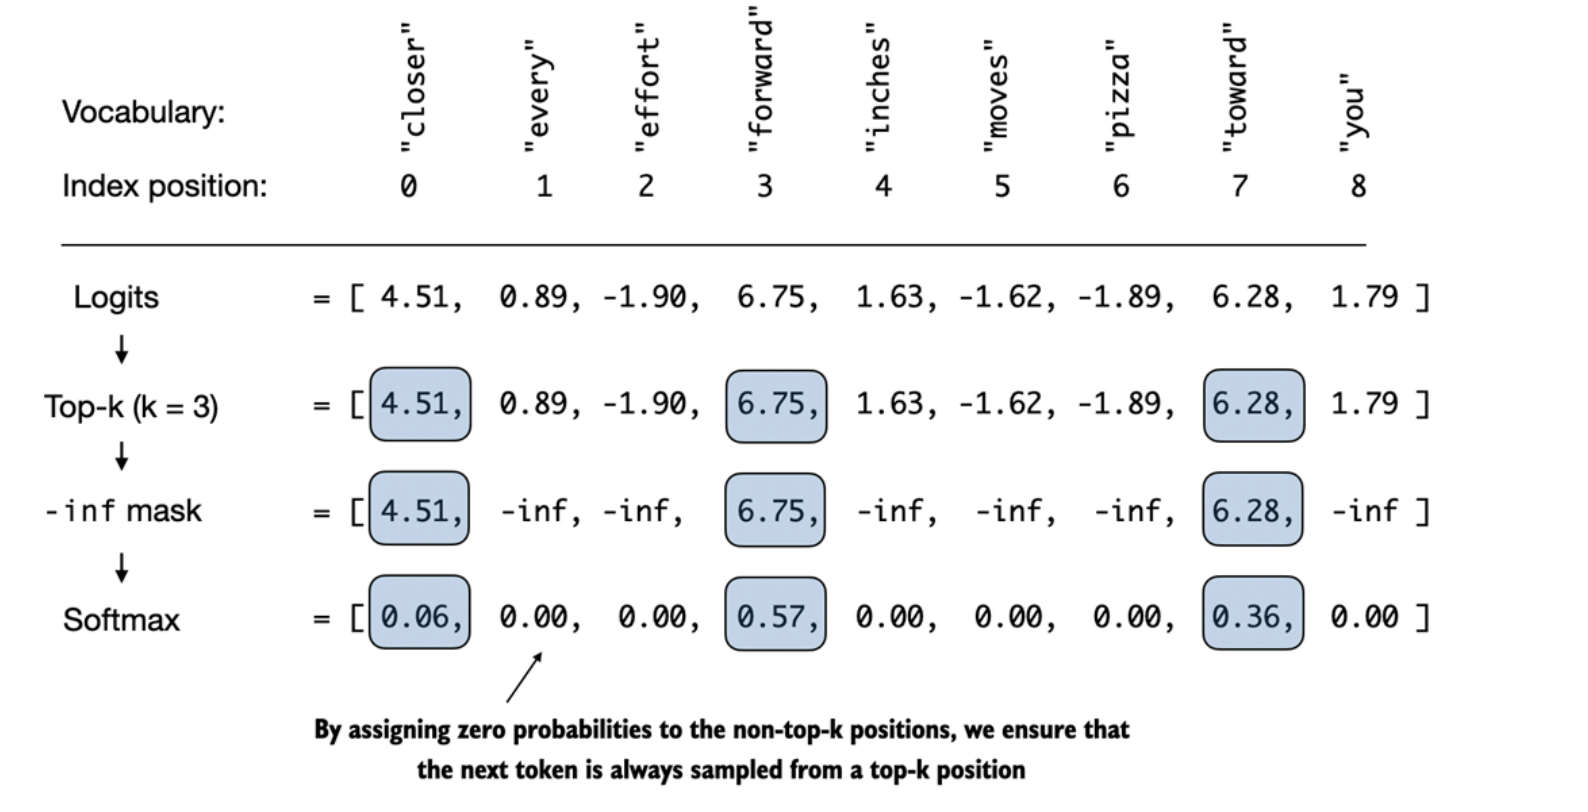

In [ ]:
# Implementation
top_k = 3
values_topk,indices_topk = torch.topk(next_token_logits,top_k)
new_logits = torch.where(condition = next_token_logits < values_topk[-1],
                         input = torch.tensor(-float("inf")),
                         other = next_token_logits)
print(new_logits)
topk_probas = torch.softmax(new_logits, dim=0)
print(topk_probas)

## 5.3.3 Modifying the text generation function

In [ ]:
def generate(model, idx, max_new_tokens, context_size, temperature=1.0, top_k=None, eos_idx=None):
    for _ in range(max_new_tokens):
        # 1. Get current input for the model (slice to context_size)
        input_ids = idx[:, -context_size:]

        # 2. Get model predictions (raw logits)
        with torch.no_grad():
            logits = model(input_ids) # Shape: (batch_size, seq_len, vocab_size)

        # We only need the logits for the last token to predict the next
        next_token_logits = logits[:, -1, :] # Shape: (batch_size, vocab_size)

        # 3. Apply Top-K filtering if specified and valid
        if top_k is not None and top_k > 0:
            # Get the top_k values and their indices for each item in the batch
            values, _ = torch.topk(next_token_logits, top_k)
            # Find the smallest value among the top_k for each item
            min_top_k_value = values[:, -1, None] # Add None to enable broadcasting across vocab_size

            # Set logits below the min_top_k_value to -inf
            next_token_logits = torch.where(next_token_logits < min_top_k_value,
                                            torch.tensor(-float("inf"), device=next_token_logits.device),
                                            next_token_logits)

        # 4. Apply Temperature scaling if specified and valid
        # Temperature is applied to the logits before softmax.
        if temperature is not None and temperature > 0.0:
            next_token_logits = next_token_logits / temperature

        # 5. Convert logits to probabilities and sample, or take argmax for deterministic generation
        if temperature is not None and temperature == 0.0:
            # Deterministic generation: pick the token with the highest logit
            idx_next = torch.argmax(next_token_logits, dim=-1, keepdim=True) # keepdim for concatenation
        else:
            # Apply softmax to get probabilities (after top-k filtering and temperature scaling)
            probabilities = torch.softmax(next_token_logits, dim=-1)

            # Sample the next token from the probabilities
            idx_next = torch.multinomial(probabilities, num_samples=1)

        # 6. Check for end-of-sequence token and concatenate the new token
        # Assuming batch size is 1 as per text_to_token_ids output and input idx
        if eos_idx is not None and idx_next.item() == eos_idx:
            break
        else:
            idx = torch.cat((idx, idx_next), dim=-1) # Use torch.cat for consistency with idx_next's shape (batch_size, 1)

    return idx

In [ ]:
model.to(device)
token_ids = generate(
model=model,
idx=text_to_token_ids("Every effort moves you", tokenizer).to(device),
max_new_tokens=15,
context_size=GPT_CONFIG_124M["context_length"],
top_k=25,
temperature=1.4
)
print("Output text:\n", token_to_text(token_ids, tokenizer)) # Corrected function name

# 5.4 Loading and saving model weights in PyTorch


In [ ]:
torch.save(model.state_dict(), "/content/model.pth")

In [ ]:
model = import_4.GPTModel(GPT_CONFIG_124M)
model.load_state_dict(torch.load("model.pth"))
model.eval()

[When we need to save both parameters and optimizers](https://gemini.google.com/share/8ba670de6581)

In [ ]:
torch.save({
"model_state_dict": model.state_dict(),
"optimizer_state_dict": optimizer.state_dict(),
},
"model_and_optimizer.pth"
)

In [ ]:
checkpoint = torch.load("model_and_optimizer.pth")
model = import_4.GPTModel(GPT_CONFIG_124M)
model.load_state_dict(checkpoint["model_state_dict"])
optimizer = torch.optim.AdamW(model.parameters(),lr = 0.004)
optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
model.train()

# 5.5 Pretrained

In [ ]:
!pip install tensorflow>=2.15.0 tqdm>=4.66


In [ ]:
import urllib.request
url = (
"https://raw.githubusercontent.com/rasbt/"
"LLMs-from-scratch/main/ch05/"
"01_main-chapter-code/gpt_download.py"
)
filename = url.split('/')[-1]
urllib.request.urlretrieve(url, filename)

('gpt_download.py', <http.client.HTTPMessage at 0x7cc391b95130>)

In [ ]:
from gpt_download import download_and_load_gpt2
settings, params = download_and_load_gpt2(model_size="124M", models_dir="gpt2")

File already exists and is up-to-date: gpt2/124M/checkpoint
File already exists and is up-to-date: gpt2/124M/encoder.json
File already exists and is up-to-date: gpt2/124M/hparams.json
File already exists and is up-to-date: gpt2/124M/model.ckpt.data-00000-of-00001
File already exists and is up-to-date: gpt2/124M/model.ckpt.index
File already exists and is up-to-date: gpt2/124M/model.ckpt.meta
File already exists and is up-to-date: gpt2/124M/vocab.bpe


In [ ]:
print("Settings",settings)
print("Params shape: ",params.keys())

Settings {'n_vocab': 50257, 'n_ctx': 1024, 'n_embd': 768, 'n_head': 12, 'n_layer': 12}
Params shape:  dict_keys(['blocks', 'b', 'g', 'wpe', 'wte'])


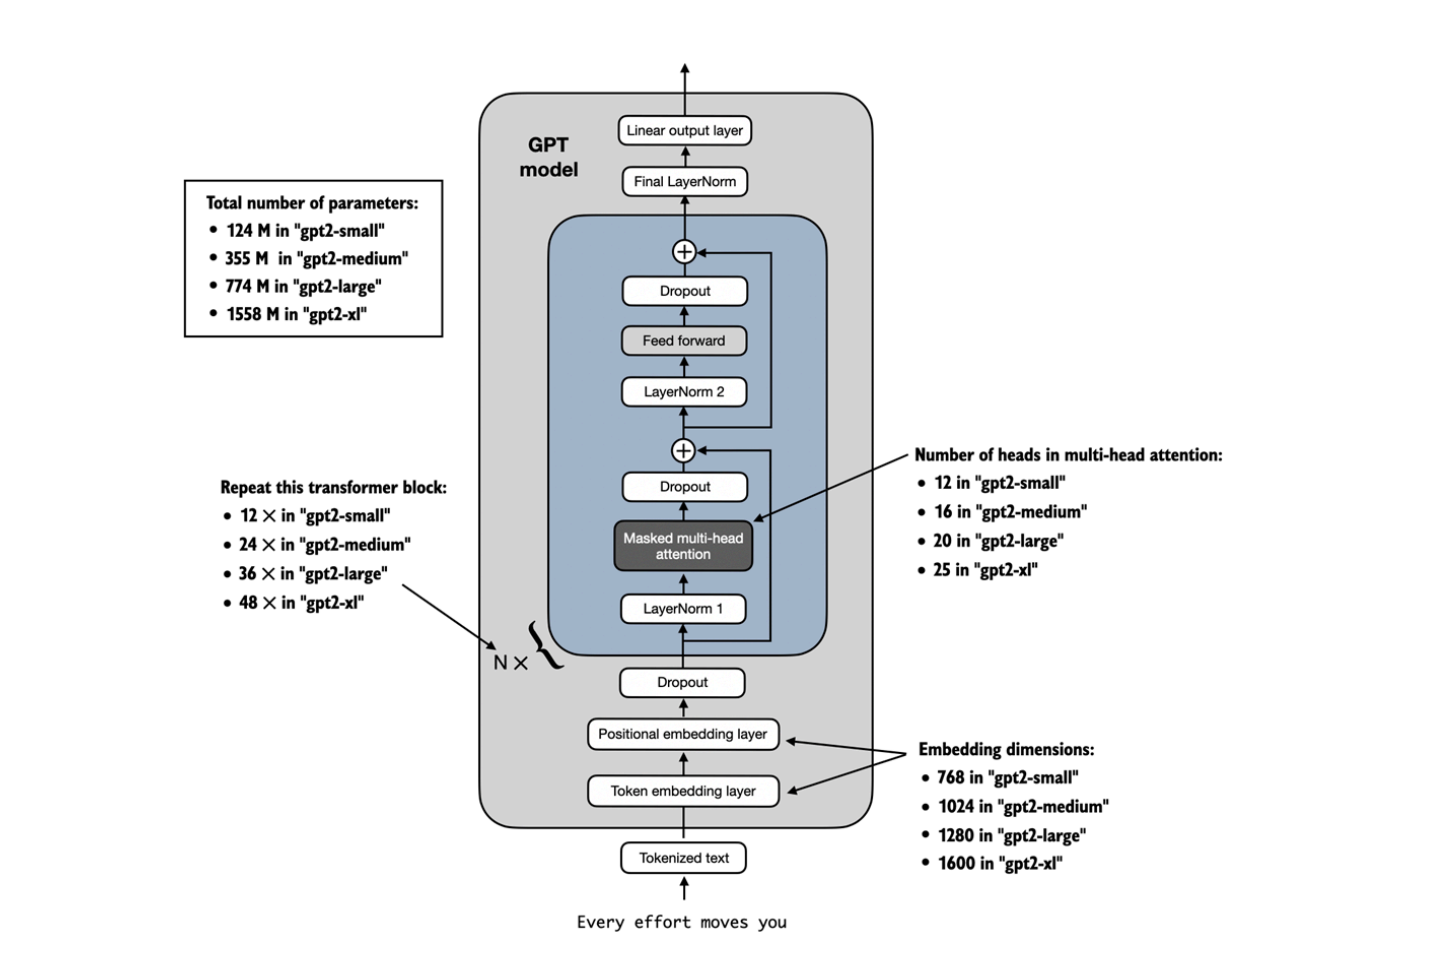

In [ ]:
model_configs = {
"gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
"gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
"gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
"gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}

In [ ]:
name_model = "gpt2-small (124M)"
NEW_CONFIG = GPT_CONFIG_124M.copy()
NEW_CONFIG.update(model_configs[name_model])
NEW_CONFIG["context_length"] = 1024
NEW_CONFIG.update({"qkv_bias" : True})

In [ ]:
NEW_CONFIG

{'vocab_size': 50257,
 'context_length': 1024,
 'emb_dim': 768,
 'n_heads': 12,
 'n_layers': 12,
 'drop_rate': 0.1,
 'qkv_bias': True}

In [ ]:
gpt = import_4.GPTModel(NEW_CONFIG)
gpt.eval()

GPTModel(
  (tok_embedded): Embedding(50257, 768)
  (pos_embedded): Embedding(1024, 768)
  (dropout): Dropout(p=0.1, inplace=False)
  (transformer): Sequential(
    (0): TransformerBlock(
      (LayerNorm1): LayerNorm()
      (LayerNorm2): LayerNorm()
      (att): MultiHeadAttention(
        (W_q): Linear(in_features=768, out_features=768, bias=True)
        (W_k): Linear(in_features=768, out_features=768, bias=True)
        (W_v): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GeLU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (LayerNorm1): LayerNorm()
      (LayerNorm2): LayerNorm()
    

In [ ]:
def assign(left, right):
    if left.shape != right.shape:
        raise ValueError(f"Shape mismatch. Left: {left.shape}, Right: {right.shape}")
    return torch.nn.Parameter(torch.tensor(right))

In [ ]:
import numpy as np
def load_weights_into_gpt(gpt, params):
    gpt.pos_embedded.weight = assign(gpt.pos_embedded.weight, params['wpe']) #A
    gpt.tok_embedded.weight = assign(gpt.tok_embedded.weight, params['wte'])
    for b in range(len(params["blocks"])): #B
        q_w, k_w, v_w = np.split( #C
        (params["blocks"][b]["attn"]["c_attn"])["w"], 3, axis=-1)

        gpt.transformer[b].att.W_q.weight = assign(
        gpt.transformer[b].att.W_q.weight, q_w.T)
        gpt.transformer[b].att.W_k.weight = assign(
        gpt.transformer[b].att.W_k.weight, k_w.T)
        gpt.transformer[b].att.W_v.weight = assign(
        gpt.transformer[b].att.W_v.weight, v_w.T)

        q_b, k_b, v_b = np.split(
        (params["blocks"][b]["attn"]["c_attn"])["b"], 3, axis=-1)

        gpt.transformer[b].att.W_q.bias = assign(
        gpt.transformer[b].att.W_q.bias, q_b)
        gpt.transformer[b].att.W_k.bias = assign(
        gpt.transformer[b].att.W_k.bias, k_b)
        gpt.transformer[b].att.W_v.bias = assign(
        gpt.transformer[b].att.W_v.bias, v_b)
        gpt.transformer[b].att.out_proj.weight = assign(
        gpt.transformer[b].att.out_proj.weight,
        params["blocks"][b]["attn"]["c_proj"]["w"].T)
        gpt.transformer[b].att.out_proj.bias = assign(
        gpt.transformer[b].att.out_proj.bias,
        params["blocks"][b]["attn"]["c_proj"]["b"])
        gpt.transformer[b].ff.layers[0].weight = assign(
        gpt.transformer[b].ff.layers[0].weight,
        params["blocks"][b]["mlp"]["c_fc"]["w"].T)
        gpt.transformer[b].ff.layers[0].bias = assign(
        gpt.transformer[b].ff.layers[0].bias,
        params["blocks"][b]["mlp"]["c_fc"]["b"])
        gpt.transformer[b].ff.layers[2].weight = assign(
        gpt.transformer[b].ff.layers[2].weight,
        params["blocks"][b]["mlp"]["c_proj"]["w"].T)
        gpt.transformer[b].ff.layers[2].bias = assign(
        gpt.transformer[b].ff.layers[2].bias,
        params["blocks"][b]["mlp"]["c_proj"]["b"])
        gpt.transformer[b].LayerNorm1.gamma = assign(
        gpt.transformer[b].LayerNorm1.gamma,
        params["blocks"][b]["ln_1"]["g"])
        gpt.transformer[b].LayerNorm1.beta = assign(
        gpt.transformer[b].LayerNorm1.beta,
        params["blocks"][b]["ln_1"]["b"])
        gpt.transformer[b].LayerNorm2.gamma = assign(
        gpt.transformer[b].LayerNorm2.gamma,
        params["blocks"][b]["ln_2"]["g"])
        gpt.transformer[b].LayerNorm2.beta = assign(
        gpt.transformer[b].LayerNorm2.beta,
        params["blocks"][b]["ln_2"]["b"])
    gpt.layernorm.scale = assign(gpt.layernorm.gamma, params["g"])
    gpt.layernorm.shift = assign(gpt.layernorm.beta, params["b"])
    gpt.output.weight = assign(gpt.output.weight, params["wte"]) #D


In [ ]:
load_weights_into_gpt(gpt, params)
gpt.to(device)


GPTModel(
  (tok_embedded): Embedding(50257, 768)
  (pos_embedded): Embedding(1024, 768)
  (dropout): Dropout(p=0.1, inplace=False)
  (transformer): Sequential(
    (0): TransformerBlock(
      (LayerNorm1): LayerNorm()
      (LayerNorm2): LayerNorm()
      (att): MultiHeadAttention(
        (W_q): Linear(in_features=768, out_features=768, bias=True)
        (W_k): Linear(in_features=768, out_features=768, bias=True)
        (W_v): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GeLU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (LayerNorm1): LayerNorm()
      (LayerNorm2): LayerNorm()
    

In [ ]:
for name, param in gpt.named_parameters():
    print(f"Feature name: {name} | Shape: {param.shape}")

Feature name: tok_embedded.weight | Shape: torch.Size([50257, 768])
Feature name: pos_embedded.weight | Shape: torch.Size([1024, 768])
Feature name: transformer.0.LayerNorm1.gamma | Shape: torch.Size([768])
Feature name: transformer.0.LayerNorm1.beta | Shape: torch.Size([768])
Feature name: transformer.0.LayerNorm2.gamma | Shape: torch.Size([768])
Feature name: transformer.0.LayerNorm2.beta | Shape: torch.Size([768])
Feature name: transformer.0.att.W_q.weight | Shape: torch.Size([768, 768])
Feature name: transformer.0.att.W_q.bias | Shape: torch.Size([768])
Feature name: transformer.0.att.W_k.weight | Shape: torch.Size([768, 768])
Feature name: transformer.0.att.W_k.bias | Shape: torch.Size([768])
Feature name: transformer.0.att.W_v.weight | Shape: torch.Size([768, 768])
Feature name: transformer.0.att.W_v.bias | Shape: torch.Size([768])
Feature name: transformer.0.att.out_proj.weight | Shape: torch.Size([768, 768])
Feature name: transformer.0.att.out_proj.bias | Shape: torch.Size([768

In [ ]:
token_ids = generate(
model=gpt,
idx=text_to_token_ids("I am", tokenizer),
max_new_tokens=25,
context_size=NEW_CONFIG["context_length"],
top_k=50,
temperature=1.5
)
print("Output text:\n", token_to_text(token_ids, tokenizer))

Output text:
 I am, the, the, the, the the, the, the, the, the, the, the, the Bog,


In [ ]:
evaluate_model(gpt,train_dataloader,valid_dataloader,eval_iter = 1)

(24.599313735961914, 24.599313735961914)